<a href="https://colab.research.google.com/github/athira-anil2327/Campus-Logistic-Optimization-problem/blob/main/Campus_Logistic_Optimization_probolem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install pulp -q
import pulp as lp

# --- 1. DATA SETUP ---
DAYS = 365
AMORT_YRS = 10
BUDGET_LIMIT = 1500000
AVG_DIST_COST = 4.35

# Facility Demands (Daily units)
facilities = {
    'MED_CENTER': 80, 'ENG_BUILDING': 30, 'SCIENCE_HALL': 35,
    'DORM_A': 55, 'DORM_B': 45, 'LIBRARY': 25
}

# Warehouse Stats: (Capacity, Construction Cost, Daily Op Cost)
warehouses = {
    'WH_NORTH': (400, 300000, 800),
    'WH_SOUTH': (350, 280000, 700),
    'WH_EAST': (450, 320000, 900)
}

# --- 2. MODEL INITIALIZATION  ---
model = lp.LpProblem("Campus_Supply_Optimization", lp.LpMinimize)

# --- 3. DECISION VARIABLES ---
# Binary: Is the warehouse open? (1=Yes, 0=No)
y = lp.LpVariable.dicts("Open", warehouses.keys(), cat='Binary')

# Continuous: How many units move from Warehouse to Facility?
x = lp.LpVariable.dicts("Route", [(w, f) for w in warehouses for f in facilities], lowBound=0)

# --- 4. OBJECTIVE FUNCTION ---
# Total Cost = (Amortized Construction + Annual Ops) + Annual Shipping
fixed_costs = lp.lpSum([y[w] * ((warehouses[w][1]/AMORT_YRS) + (warehouses[w][2]*DAYS)) for w in warehouses])
variable_costs = lp.lpSum([x[w,f] * AVG_DIST_COST for w in warehouses for f in facilities])
model += fixed_costs + variable_costs

# --- 5. CONSTRAINTS ---
# Demand: Each facility must receive exactly its annual demand
for f, d in facilities.items():
    model += lp.lpSum([x[w,f] for w in warehouses]) == d * DAYS

# Capacity: Shipments from warehouse must not exceed capacity if open
for w in warehouses:
    model += lp.lpSum([x[w,f] for f in facilities]) <= warehouses[w][0] * DAYS * y[w]

# Redundancy: Must select EXACTLY 2 warehouses
model += lp.lpSum([y[w] for w in warehouses]) == 2

# --- 6. SOLVE & RESULTS ---
model.solve(lp.PULP_CBC_CMD(msg=0))

print(f"Optimization Status: {lp.LpStatus[model.status]}")
print(f"Total Annual Cost: ${lp.value(model.objective):,.2f}")
print(f"Budget Check: {'PASS' if lp.value(model.objective) <= BUDGET_LIMIT else 'FAIL'}")
print("-" * 40)

for w in warehouses:
    if lp.value(y[w]) == 1:
        annual_flow = sum(lp.value(x[w,f]) for f in facilities)
        print(f"WAREHOUSE {w} is ACTIVE")
        print(f" -> Shipping {annual_flow:,.0f} units annually.")

Optimization Status: Optimal
Total Annual Cost: $1,034,192.50
Budget Check: PASS
----------------------------------------
WAREHOUSE WH_NORTH is ACTIVE
 -> Shipping 74,825 units annually.
WAREHOUSE WH_SOUTH is ACTIVE
 -> Shipping 23,725 units annually.


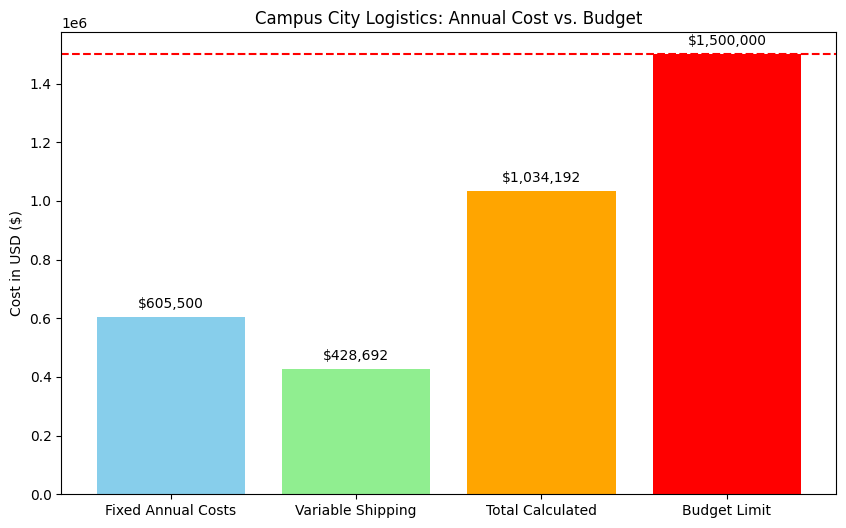

In [9]:
import matplotlib.pyplot as plt

# Data for visualization
categories = ['Fixed Annual Costs', 'Variable Shipping', 'Total Calculated', 'Budget Limit']
# Using the values from your successful run
costs = [605500, 428692.50, 1034192.50, 1500000]

plt.figure(figsize=(10, 6))
colors = ['skyblue', 'lightgreen', 'orange', 'red']
bars = plt.bar(categories, costs, color=colors)

# Adding labels and titles
plt.ylabel('Cost in USD ($)')
plt.title('Campus City Logistics: Annual Cost vs. Budget')
plt.axhline(y=1500000, color='red', linestyle='--', label='Budget Ceiling')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20000, f'${yval:,.0f}', ha='center', va='bottom')

plt.show()

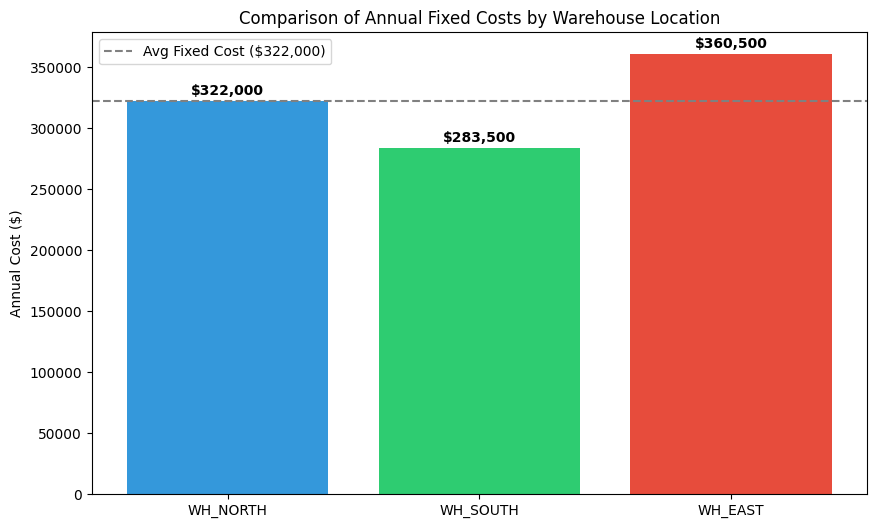

In [12]:
import matplotlib.pyplot as plt

# Calculations based on provided data
# Fixed Cost = (Construction / 10) + (Daily Op * 365)
labels = ['WH_NORTH', 'WH_SOUTH', 'WH_EAST']
fixed_costs = [
    (300000/10) + (800*365), # North: $322,000
    (280000/10) + (700*365), # South: $283,500
    (320000/10) + (900*365)  # East: $360,500
]

# Create the visual
plt.figure(figsize=(10, 6))
plt.bar(labels, fixed_costs, color=['#3498db', '#2ecc71', '#e74c3c'])

# Add horizontal line for the average fixed cost
avg_fixed = sum(fixed_costs) / 3
plt.axhline(y=avg_fixed, color='gray', linestyle='--', label=f'Avg Fixed Cost (${avg_fixed:,.0f})')

plt.title('Comparison of Annual Fixed Costs by Warehouse Location')
plt.ylabel('Annual Cost ($)')
plt.legend()

# Annotate values
for i, v in enumerate(fixed_costs):
    plt.text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.show()